# Movie Review Sentiment: Lexicon-Based VADER vs a Supervised TF-IDF Classifier

## Project Overview

This project classifies 6,000 English movie reviews as positive or negative using two very different approaches:

- **VADER**: a rule-based sentiment lexicon that needs no training data.
- **TF-IDF + Logistic Regression**: a supervised linear model trained on labeled reviews.

Both models are evaluated on the same held-out test set. The error analysis then looks at *why* the lexicon approach falls short on long-form reviews, including a direct test of whether the final sentence carries the reviewer's verdict.

**Tools:** Python, pandas, NLTK (VADER, sentence tokenizer), scikit-learn, matplotlib, seaborn.

## Objective

Measure how well an off-the-shelf sentiment lexicon classifies full-length movie reviews, quantify the gap to a simple supervised baseline, and identify the specific patterns that cause lexicon-based errors.

## Dataset

| Property | Value |
|---|---|
| File | `data/movie_reviews.tsv` (tab-separated) |
| Columns | `label` (`pos` / `neg`), `review` (raw text) |
| Size | 6,000 reviews, balanced 3,000 / 3,000 |
| Source | Distributed with the Pierian Data *NLP with Python* course materials. The text (including `<br />` tags) appears to be a sample of IMDb reviews, likely from the [Large Movie Review Dataset](https://ai.stanford.edu/~amaas/data/sentiment/) (Maas et al., 2011). |

The redistribution terms of this course file are not documented, so it is **not included in the repository**. To run the notebook, place the file at `data/movie_reviews.tsv`, or build an equivalent file from the public Large Movie Review Dataset with the same two columns.

## Setup and Imports

In [ ]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
    precision_recall_fscore_support,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline

RANDOM_SEED = 42
DATA_PATH = Path("data") / "movie_reviews.tsv"

# Consistent plot style: label colors for classes, separate colors for models
sns.set_theme(style="whitegrid", context="notebook")
LABEL_ORDER = ["neg", "pos"]
LABEL_COLORS = {"neg": "#eb6834", "pos": "#2a78d6"}
MODEL_COLORS = {"VADER": "#1baf7a", "TF-IDF + LogReg": "#4a3aa7"}
pd.set_option("display.max_colwidth", 120)


def ensure_nltk_resource(resource_path, package_name):
    """Download an NLTK resource only if it is not already installed."""
    try:
        nltk.data.find(resource_path)
    except LookupError:
        nltk.download(package_name, quiet=True)


ensure_nltk_resource("sentiment/vader_lexicon.zip", "vader_lexicon")
ensure_nltk_resource("tokenizers/punkt_tab", "punkt_tab")

## Data Preparation

Cleaning steps:

1. Drop rows with a missing or blank review.
2. Replace HTML line breaks (`<br />`) with spaces. About half of the reviews contain them, and they would otherwise leak tokens such as `br` into the TF-IDF vocabulary.
3. Drop exact duplicate reviews so the same text cannot appear in both the training and test sets.

In [ ]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at {DATA_PATH.resolve()}. See the Dataset section for instructions."
    )

raw_reviews = pd.read_csv(DATA_PATH, sep="\t")
print(f"Raw rows: {len(raw_reviews):,}")

Raw rows: 6,000


In [ ]:
HTML_TAG_PATTERN = re.compile(r"<[^>]+>")


def clean_review_text(text):
    """Strip HTML tags and collapse repeated whitespace."""
    text = HTML_TAG_PATTERN.sub(" ", text)
    return re.sub(r"\s+", " ", text).strip()


reviews = raw_reviews.dropna(subset=["label", "review"]).copy()
reviews["review"] = reviews["review"].astype(str).map(clean_review_text)
reviews = reviews[reviews["review"].ne("")]

rows_before_dedup = len(reviews)
reviews = reviews.drop_duplicates(subset="review").reset_index(drop=True)

print(f"Removed missing/blank reviews: {len(raw_reviews) - rows_before_dedup}")
print(f"Removed duplicate reviews:     {rows_before_dedup - len(reviews)}")
print(f"Clean rows:                    {len(reviews):,}")

Removed missing/blank reviews: 20
Removed duplicate reviews:     15
Clean rows:                    5,965


## Exploratory Analysis

The classes remain balanced after cleaning, so accuracy is a meaningful headline metric. Positive and negative reviews have similar length distributions, so length alone does not separate the classes.

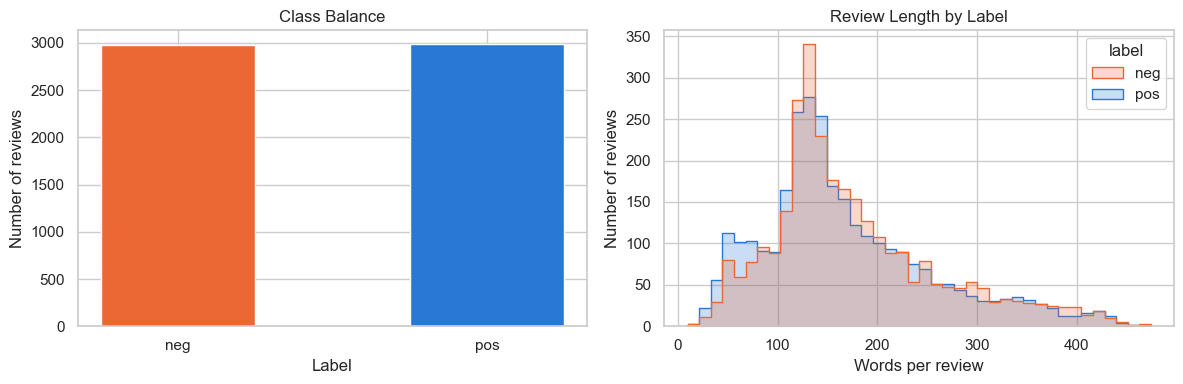

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
neg,2982.0,176.1,85.5,10.0,122.0,153.0,217.8,474.0
pos,2983.0,168.7,86.7,17.0,115.0,148.0,214.0,463.0


In [ ]:
reviews["word_count"] = reviews["review"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

label_counts = reviews["label"].value_counts().reindex(LABEL_ORDER)
axes[0].bar(label_counts.index, label_counts.values,
            color=[LABEL_COLORS[label] for label in label_counts.index], width=0.5)
axes[0].set_title("Class Balance")
axes[0].set_xlabel("Label")
axes[0].set_ylabel("Number of reviews")

sns.histplot(data=reviews, x="word_count", hue="label", hue_order=LABEL_ORDER, palette=LABEL_COLORS,
             bins=40, element="step", ax=axes[1])
axes[1].set_title("Review Length by Label")
axes[1].set_xlabel("Words per review")
axes[1].set_ylabel("Number of reviews")

plt.tight_layout()
plt.show()

reviews.groupby("label")["word_count"].describe().round(1)

## Model Development

### Train / Validation / Test Split

The data is split 60 / 20 / 20 with stratification:

- **Train**: fits the TF-IDF model.
- **Validation**: selects the VADER decision threshold and the logistic regression regularization strength.
- **Test**: used once, for the final comparison.

VADER has no trainable parameters, but its decision threshold is still a modeling choice. Tuning it on the validation set keeps the comparison fair and avoids selecting it on test data.

In [ ]:
train_df, temp_df = train_test_split(
    reviews, test_size=0.4, stratify=reviews["label"], random_state=RANDOM_SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df["label"], random_state=RANDOM_SEED
)
train_df, val_df, test_df = train_df.copy(), val_df.copy(), test_df.copy()

pd.DataFrame({
    "rows": [len(train_df), len(val_df), len(test_df)],
    "share_positive": [split["label"].eq("pos").mean().round(3) for split in (train_df, val_df, test_df)],
}, index=["train", "validation", "test"])

,rows,share_positive
train,3579,0.5
validation,1193,0.5
test,1193,0.5


### Baseline: Majority Class

A classifier that always predicts the most frequent class sets the floor. On balanced data it should score about 50%.

In [ ]:
majority_baseline = DummyClassifier(strategy="most_frequent")
majority_baseline.fit(train_df[["review"]], train_df["label"])

DummyClassifier(strategy='most_frequent')

### Model 1: VADER

VADER returns a `compound` score in [-1, 1] for each text. A review is labeled positive when its score is at or above a threshold. The usual default is 0.

The analyzer is created once and applied to every split.

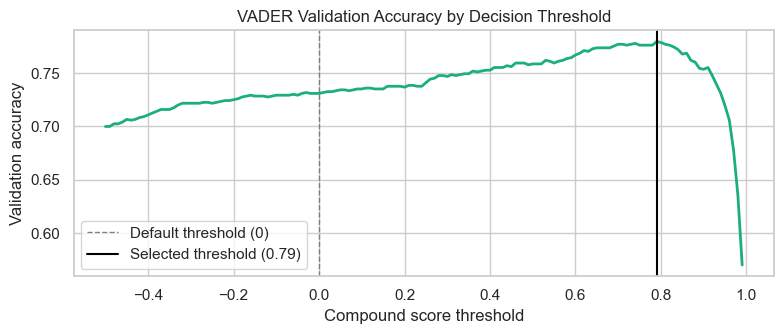

In [ ]:
vader = SentimentIntensityAnalyzer()


def vader_compound(text):
    return vader.polarity_scores(text)["compound"]


for split in (train_df, val_df, test_df):
    split["vader_score"] = split["review"].map(vader_compound)


def predict_from_score(scores, threshold):
    return np.where(scores >= threshold, "pos", "neg")


# Select the threshold that maximizes validation accuracy
candidate_thresholds = np.round(np.arange(-0.5, 1.0, 0.01), 2)
validation_accuracy = [
    accuracy_score(val_df["label"], predict_from_score(val_df["vader_score"], t))
    for t in candidate_thresholds
]
best_vader_threshold = candidate_thresholds[int(np.argmax(validation_accuracy))]

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(candidate_thresholds, validation_accuracy, color=MODEL_COLORS["VADER"], linewidth=2)
ax.axvline(0, color="gray", linestyle="--", linewidth=1, label="Default threshold (0)")
ax.axvline(best_vader_threshold, color="black", linewidth=1.5,
           label=f"Selected threshold ({best_vader_threshold:.2f})")
ax.set_title("VADER Validation Accuracy by Decision Threshold")
ax.set_xlabel("Compound score threshold")
ax.set_ylabel("Validation accuracy")
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

### Model 2: TF-IDF + Logistic Regression

Unigrams and bigrams are weighted with TF-IDF and fed to a logistic regression classifier. Bigrams capture short phrases such as "not good" or "waste of". Only the regularization strength `C` is tuned, using the validation set.

In [ ]:
def build_tfidf_model(C):
    return make_pipeline(
        TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True, strip_accents="unicode"),
        LogisticRegression(C=C, max_iter=2000, random_state=RANDOM_SEED),
    )


c_search = []
for C in [0.1, 0.3, 1, 3, 10, 30]:
    candidate = build_tfidf_model(C).fit(train_df["review"], train_df["label"])
    c_search.append({"C": C, "val_accuracy": accuracy_score(val_df["label"], candidate.predict(val_df["review"]))})

c_search = pd.DataFrame(c_search)
best_C = c_search.loc[c_search["val_accuracy"].idxmax(), "C"]
tfidf_model = build_tfidf_model(best_C).fit(train_df["review"], train_df["label"])

print(f"Selected C = {best_C}")
c_search.round(4)

Selected C = 10.0


,C,val_accuracy
0,0.1,0.8969
1,0.3,0.9070
2,1.0,0.9237
3,3.0,0.9271
4,10.0,0.9313
5,30.0,0.9212


## Model Evaluation

All models are scored on the untouched test set. Macro F1 and per-class recall are reported alongside accuracy because the main VADER failure is uneven performance across classes, which accuracy alone hides.

In [ ]:
test_predictions = {
    "Majority class": majority_baseline.predict(test_df[["review"]]),
    "VADER (threshold 0)": predict_from_score(test_df["vader_score"], 0.0),
    f"VADER (threshold {best_vader_threshold:.2f})": predict_from_score(test_df["vader_score"], best_vader_threshold),
    "TF-IDF + LogReg": tfidf_model.predict(test_df["review"]),
}
positive_probability = tfidf_model.predict_proba(test_df["review"])[:, list(tfidf_model.classes_).index("pos")]
test_scores = {
    "VADER (threshold 0)": test_df["vader_score"],
    f"VADER (threshold {best_vader_threshold:.2f})": test_df["vader_score"],
    "TF-IDF + LogReg": positive_probability,
}
y_test = test_df["label"]
y_test_binary = y_test.eq("pos").astype(int)

results = []
for model_name, predictions in test_predictions.items():
    _, recall, _, _ = precision_recall_fscore_support(y_test, predictions, labels=["neg", "pos"], zero_division=0)
    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Macro F1": f1_score(y_test, predictions, average="macro"),
        "Recall (neg)": recall[0],
        "Recall (pos)": recall[1],
        "ROC AUC": roc_auc_score(y_test_binary, test_scores[model_name]) if model_name in test_scores else np.nan,
    })

results_table = pd.DataFrame(results).set_index("Model").round(3)
results_table

,Accuracy,Macro F1,Recall (neg),Recall (pos),ROC AUC
Model,,,,,
Majority class,0.500,0.333,0.000,1.000,NaN
VADER (threshold 0),0.749,0.744,0.610,0.889,0.844
VADER (threshold 0.79),0.771,0.771,0.765,0.777,0.844
TF-IDF + LogReg,0.931,0.931,0.923,0.940,0.982


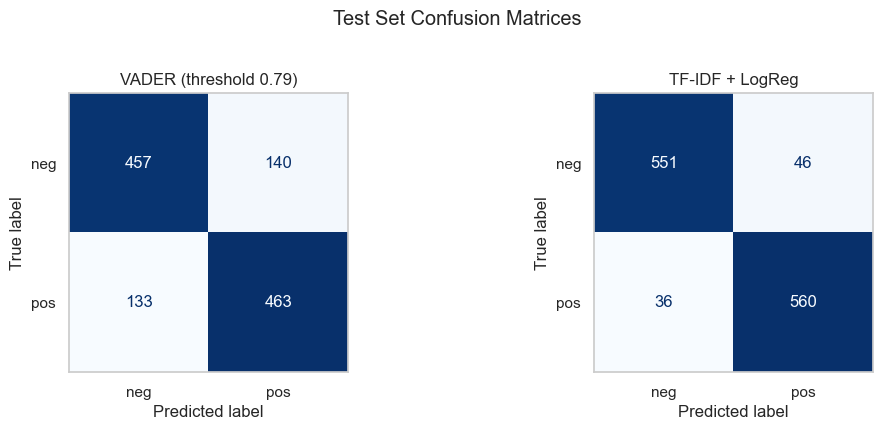

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, model_name in zip(axes, [f"VADER (threshold {best_vader_threshold:.2f})", "TF-IDF + LogReg"]):
    ConfusionMatrixDisplay.from_predictions(
        y_test, test_predictions[model_name], labels=["neg", "pos"],
        cmap="Blues", colorbar=False, ax=ax,
    )
    ax.set_title(model_name)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.grid(False)
plt.suptitle("Test Set Confusion Matrices", y=1.02)
plt.tight_layout()
plt.show()

## Error Analysis

### 1. VADER's positive skew

If VADER scored reviews symmetrically, negative reviews would cluster below zero. The distribution below shows how far negative reviews actually spread into positive territory.

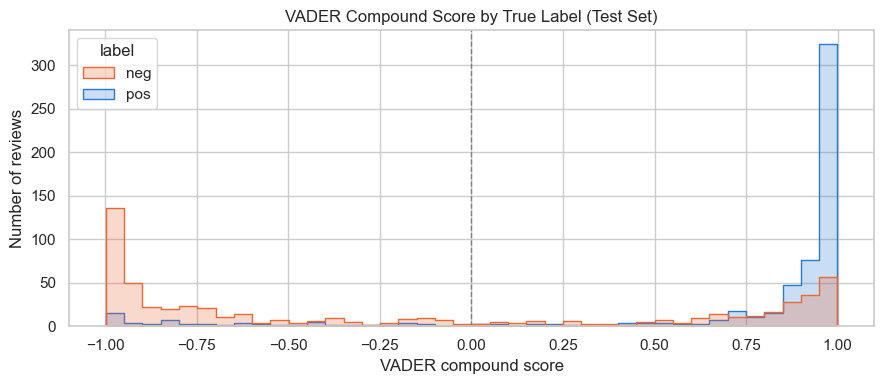

Negative reviews with a non-negative VADER score: 39.0%


In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(data=test_df, x="vader_score", hue="label", hue_order=LABEL_ORDER, palette=LABEL_COLORS,
             bins=40, element="step", ax=ax)
ax.axvline(0, color="gray", linestyle="--", linewidth=1)
ax.set_title("VADER Compound Score by True Label (Test Set)")
ax.set_xlabel("VADER compound score")
ax.set_ylabel("Number of reviews")
plt.tight_layout()
plt.show()

share_neg_scored_positive = (test_df.loc[test_df["label"] == "neg", "vader_score"] >= 0).mean()
print(f"Negative reviews with a non-negative VADER score: {share_neg_scored_positive:.1%}")

### 2. Does the final sentence carry the verdict?

A common explanation for VADER's errors is that reviewers praise parts of a film and save their verdict for the end. To test this, each review is split into sentences and scored three ways:

- **Full review**: VADER on the whole text (the standard approach).
- **Mean of sentences**: the average sentence-level compound score.
- **Last sentence**: the compound score of the final sentence only.

ROC AUC is used for this comparison because it does not depend on any threshold. The comparison runs on the validation set, so the test set stays reserved for the final results.

In [ ]:
def sentence_level_scores(text):
    sentence_scores = [vader_compound(sentence) for sentence in nltk.sent_tokenize(text)]
    return pd.Series({
        "mean_of_sentences": np.mean(sentence_scores),
        "last_sentence": sentence_scores[-1],
    })


val_sentence_scores = val_df["review"].apply(sentence_level_scores)
y_val_binary = val_df["label"].eq("pos").astype(int)

pd.DataFrame({
    "ROC AUC (validation)": {
        "Full review": roc_auc_score(y_val_binary, val_df["vader_score"]),
        "Mean of sentences": roc_auc_score(y_val_binary, val_sentence_scores["mean_of_sentences"]),
        "Last sentence": roc_auc_score(y_val_binary, val_sentence_scores["last_sentence"]),
    }
}).round(3)

,ROC AUC (validation)
Full review,0.839
Mean of sentences,0.872
Last sentence,0.702


### 3. Accuracy by review length

Test reviews are grouped into length quartiles to check whether either model degrades on longer texts.

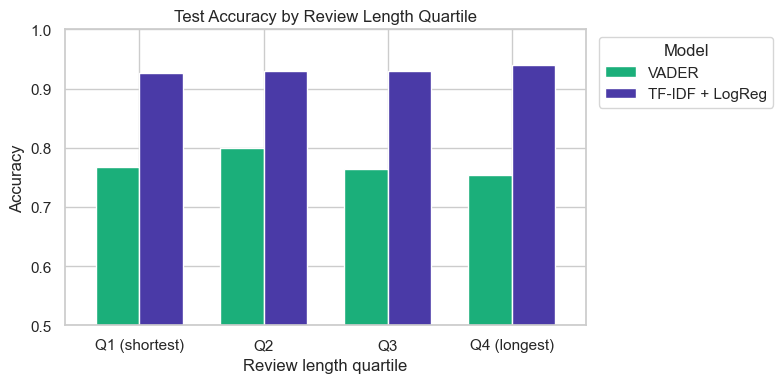

,VADER,TF-IDF + LogReg
length_quartile,,
Q1 (shortest),0.767,0.927
Q2,0.800,0.930
Q3,0.764,0.929
Q4 (longest),0.754,0.939


In [ ]:
length_analysis = test_df[["label", "word_count"]].copy()
length_analysis["length_quartile"] = pd.qcut(
    length_analysis["word_count"], q=4,
    labels=["Q1 (shortest)", "Q2", "Q3", "Q4 (longest)"],
)
vader_tuned_name = f"VADER (threshold {best_vader_threshold:.2f})"
length_analysis["VADER"] = test_predictions[vader_tuned_name] == length_analysis["label"]
length_analysis["TF-IDF + LogReg"] = test_predictions["TF-IDF + LogReg"] == length_analysis["label"]

accuracy_by_length = length_analysis.groupby("length_quartile", observed=True)[["VADER", "TF-IDF + LogReg"]].mean()

ax = accuracy_by_length.plot(kind="bar", figsize=(8, 4), width=0.7, rot=0,
                             color=[MODEL_COLORS["VADER"], MODEL_COLORS["TF-IDF + LogReg"]])
ax.set_title("Test Accuracy by Review Length Quartile")
ax.set_xlabel("Review length quartile")
ax.set_ylabel("Accuracy")
ax.set_ylim(0.5, 1.0)
ax.legend(title="Model", loc="upper left", bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

accuracy_by_length.round(3)

### 4. What the supervised model learned

The largest logistic regression coefficients show which terms push a prediction toward each class. Several strong negative cues, such as `plot`, `minutes`, `money`, and `even`, are not in the VADER lexicon at all. They only signal sentiment in the context of movie reviews ("the plot made no sense", "90 minutes I won't get back").

In [ ]:
vectorizer, classifier = tfidf_model[0], tfidf_model[-1]
feature_weights = pd.Series(classifier.coef_[0], index=vectorizer.get_feature_names_out())

pd.DataFrame({
    "Most negative terms": feature_weights.nsmallest(15).index,
    "Most positive terms": feature_weights.nlargest(15).index,
})

,Most negative terms,Most positive terms
0,bad,great
1,worst,love
2,the worst,excellent
3,awful,best
4,waste,wonderful
5,terrible,perfect
6,no,amazing
7,boring,loved
8,even,the best
9,horrible,highly


### 5. Confident VADER mistakes

These are the five negative test reviews that VADER scored as most positive, shown with their opening and closing lines. The table after them counts where the two models agree and disagree on the test set.

In [ ]:
def opening_and_closing(text, n_chars=160):
    if len(text) <= 2 * n_chars:
        return text
    return f"{text[:n_chars]} [...] {text[-n_chars:]}"


test_results = test_df.assign(
    vader_pred=test_predictions[vader_tuned_name],
    tfidf_pred=test_predictions["TF-IDF + LogReg"],
)
confident_vader_errors = (
    test_results[(test_results["label"] == "neg") & (test_results["vader_pred"] == "pos")]
    .nlargest(5, "vader_score")
)
with pd.option_context("display.max_colwidth", None):
    display(confident_vader_errors.assign(excerpt=confident_vader_errors["review"].map(opening_and_closing))[
        ["vader_score", "tfidf_pred", "excerpt"]
    ])

,vader_score,tfidf_pred,excerpt
4640,0.9960,pos,"I have to agree with most everyone's opinion that this show was poorly produced as well as written.The acting was not much more above the lower production value [...] minder of what Laura Harris can simply state about her time on the show and I bet she would quote many a young actors words of defense by saying ""It's a start!"""
2007,0.9939,neg,"I don't know why I keep doing this to myself!! I keep on defending the Dutch and Belgian cinema and claim that it should get more credit and chances...and then [...] He never ever mentions this thing he starred in, though. Like everybody else in The Netherlands, he's trying to convince himself Intensive Care never happened."
1025,0.9921,neg,"When I was younger I really enjoyed watching bad television. We've all been guilty of it at some time or another, but my excuse for watching things like ""Buck R [...] more style (like Farscape) and substance (like the reimagined Battlestar Galactica) have smaller, less rabid fanbases than this pap. It just doesn't deserve it."
2622,0.9919,neg,"Yeah, well, I definitely had regrets about giving up my Saturday night watching this strange little, yet very long, movie. Apparently neither did the main chara [...] movie where unbelievable occurrences just seem to happen without buildup. Basic movie, not 100% terrible, but you can do better with foreign gay-themed movies."
5908,0.9915,neg,"Joe Don Baker. He was great in ""Walking Tall"" and had a good bit-part in ""Goldeneye"", but here in ""Final Justice"" all hope is gone...the dark side has won. As w [...] ce, catch THIS version of ""Final Justice"". Two stars for ""Final Justice"". Ten for the MST3K version ONLY. Oh, and try not to visit Malta when Joe Don's in town."


In [ ]:
error_overlap = pd.crosstab(
    test_results["vader_pred"] == test_results["label"],
    test_results["tfidf_pred"] == test_results["label"],
    rownames=["VADER correct"], colnames=["TF-IDF correct"],
)
error_overlap

TF-IDF correct,False,True
VADER correct,,
False,43,230
True,39,881


## Key Findings

| Model (test set, n = 1,193) | Accuracy | Macro F1 | ROC AUC |
|---|---|---|---|
| Majority class | 0.500 | 0.333 | – |
| VADER, default threshold (0) | 0.749 | 0.744 | 0.844 |
| VADER, tuned threshold (0.79) | 0.771 | 0.771 | 0.844 |
| TF-IDF + Logistic Regression | **0.931** | **0.931** | **0.982** |

- **The supervised model clearly wins.** TF-IDF + logistic regression beats the best VADER configuration by 16 accuracy points. It fixes 230 of VADER's test errors, while VADER is right on only 39 reviews that the supervised model gets wrong.
- **VADER is biased toward positive scores on long reviews.** At the default threshold it catches 89% of positive reviews but only 61% of negative ones. 39% of negative test reviews receive a non-negative compound score.
- **Moving the threshold balances the errors, but only up to a point.** Raising the cutoff to 0.79 (selected on validation data) equalizes recall across classes and adds about 2 accuracy points. The ranking quality (AUC 0.844) stays the same, so threshold tuning cannot close the gap.
- **The "verdict in the last sentence" hypothesis does not hold here.** Scoring only the final sentence performs much worse (validation AUC 0.702) than scoring the full review (0.839). Averaging sentence-level scores works best (0.872). This suggests that sentiment is spread across the whole review, and that averaging per sentence reduces the influence of a few strongly worded sentences.
- **Review length is not the main driver of errors.** Accuracy varies by only a few points across length quartiles for both models, with no consistent trend.
- **Domain vocabulary is the main difference.** The supervised model relies on movie-specific negative cues (`plot`, `minutes`, `money`, `waste`) that a general-purpose lexicon either lacks or weights weakly.

## Limitations

- The dataset is a 6,000-review sample from a single domain (movies). The results may not carry over to short social media text, where VADER is known to perform better.
- The supervised model has a structural advantage: it learns domain vocabulary from labeled data. VADER is used here as a zero-training reference, not as a tuned competitor.
- Only one random split is evaluated. Cross-validation would give confidence intervals around these scores.

## Next Steps

- Fine-tune a pretrained transformer (for example, DistilBERT) and compare it against the TF-IDF baseline.
- Combine VADER sentence scores with position features (for example, giving later sentences more weight) as inputs to a small supervised model.
- Evaluate on a second domain, such as product reviews, to measure how well each approach generalizes.
